# PROYECTO MÓDULO 7 CIENCIA DE DATOS

## Indicaciones

In [8]:
# Proyecto Módulo 6 - Curso Ciencia de Dato -
# Reinaldo Elgueta A.


##LECCIÓN 1:  Fundamentos del Aprendizaje No Supervisado

📌 Objetivo: Comprender los fundamentos teóricos del aprendizaje no
supervisado y sus diferencias con el aprendizaje supervisado.


📍 Tareas a desarrollar:
- Identificar las principales tareas que resuelve el aprendizaje no
supervisado
- Clasificar técnicas por tipo (clusterización, reducción, asociación)
- Analizar casos reales de aplicación

### RESPUESTAS:

EN DOCUMENTO PDF ADJUNTO

##LECCIÓN 2:Técnicas de Clusterización


📌 Objetivo: Conocer en profundidad la técnica de clusterización y sus
aplicaciones.


📍 Tareas a desarrollar:
- Definir escenarios donde se aplique clusterización
- Explicar ventajas y desventajas de la técnica
- Comparar K-Means, DBSCAN y agrupamiento jerárquico teóricamente
- Asociar cada algoritmo a un tipo de dato o problema real

### RESPUESTAS:

EN DOCUMENTO PDF ADJUNTO **texto en negrita**

## EXTRA

***Creación de DataSet y limpieza de ésta***

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Configuración
np.random.seed(42)
n_clientes = 500

# Se prefiere elegir generar datos y no usar la sugerida por un tema de seguridad interna y no dar autorizaciones a la plataforma en cuestión.
# Generación de datos base
data = {
    'Edad': np.random.randint(18, 70, n_clientes).astype(float),
    'Ingreso_Anual_USD': np.random.normal(50000, 15000, n_clientes),
    'Puntaje_Gasto': np.random.randint(1, 100, n_clientes).astype(float),
    'Frecuencia_Compra': np.random.poisson(10, n_clientes).astype(float)
}

df = pd.DataFrame(data)

# --- INSERCIÓN DE ERRORES PARA LIMPIEZA ---

# 1. Insertar Valores Nulos (NaN)
for col in df.columns:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

# 2. Insertar Outliers (Ej: Ingresos extremadamente altos o edades imposibles)
df.loc[0, 'Ingreso_Anual_USD'] = 2000000  # Un ingreso de 2 millones
df.loc[1, 'Edad'] = -5                    # Edad negativa
df.loc[2, 'Puntaje_Gasto'] = 999          # Puntaje fuera de rango (1-100)

print("Dataset con errores generado. Resumen de nulos:")
print(df.isnull().sum())

Dataset con errores generado. Resumen de nulos:
Edad                 25
Ingreso_Anual_USD    25
Puntaje_Gasto        25
Frecuencia_Compra    25
dtype: int64


In [10]:
# --- ETAPA DE LIMPIEZA DE DATOS (LECCIÓN 3) ---

# 1. Copia de seguridad del dataset original
df_limpio = df.copy()

# 2. Manejo de Outliers (Valores atípicos) mediante filtros lógicos
# Eliminamos registros con lógica imposible (Edades < 0) o valores extremos de negocio
df_limpio = df_limpio[
    (df_limpio['Edad'] >= 18) &
    (df_limpio['Ingreso_Anual_USD'] < 1000000) &
    (df_limpio['Puntaje_Gasto'] <= 100)
]

# 3. Tratamiento de Valores Nulos (NaN)
# En este caso, imputamos con la mediana para no perder el 5% de los datos
for col in df_limpio.columns:
    mediana = df_limpio[col].median()
    df_limpio[col] = df_limpio[col].fillna(mediana)

# 4. Verificación post-limpieza
print("Limpieza completada.")
print(f"Registros originales: {len(df)}")
print(f"Registros tras limpieza: {len(df_limpio)}")
print("\nConteo de nulos final:")
print(df_limpio.isnull().sum())

# --- PREPARACIÓN PARA REDUCCIÓN DIMENSIONAL ---

# 5. Escalado de datos (StandardScaler)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_limpio)

print("\nDatos escalados y listos para PCA y t-SNE.")

Limpieza completada.
Registros originales: 500
Registros tras limpieza: 427

Conteo de nulos final:
Edad                 0
Ingreso_Anual_USD    0
Puntaje_Gasto        0
Frecuencia_Compra    0
dtype: int64

Datos escalados y listos para PCA y t-SNE.


###Justificación del Tratamiento de Datos
Para garantizar la calidad de la segmentación en "Retail Insights S.A.", se aplicó un protocolo de limpieza basado en los siguientes criterios:


Tratamiento de Valores Nulos (NaN): Se optó por la imputación mediante la mediana en lugar de la eliminación de registros. Esta decisión se tomó para preservar el tamaño de la muestra y porque la mediana es un estadístico robusto que no se ve afectado por los valores extremos, a diferencia de la media.


Gestión de Outliers: Se eliminaron registros con inconsistencias lógicas (como edades negativas o puntajes de gasto fuera del rango 1-100) para evitar distorsiones en el cálculo de distancias de los algoritmos de clusterización.


Estandarización: Se aplicó StandardScaler para que todas las variables (Edad, Ingresos, Frecuencia) tengan media 0 y desviación estándar 1. Esto es crítico para PCA, ya que este método es sensible a las diferentes escalas de magnitud de los datos originales

##LECCIÓN 3: Reducción Dimensional y Preprocesamiento


📌 Objetivo: Aprender a aplicar técnicas de reducción de dimensionalidad
como PCA y t-SNE.


📍 Tareas a desarrollar:

- Preparar un dataset de alta dimensión
- Implementar PCA y t-SNE con scikit-learn
- Visualizar y comparar los resultados
- Justificar cuál técnica conviene para el problema actual

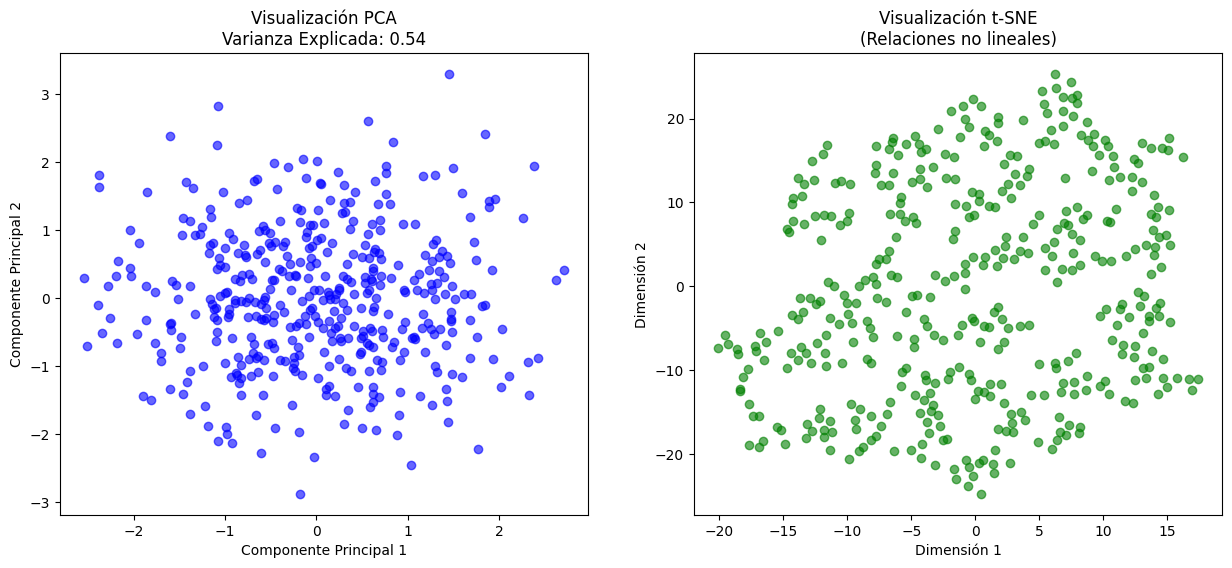

In [12]:
# --- PASO PREVIO: EJECUTAR LA REDUCCIÓN (Lección 3) ---

# 1. Configurar y aplicar PCA
# Usamos 2 componentes para poder graficar en un plano X-Y
pca = PCA(n_components=2)
pca_results = pca.fit_transform(df_scaled)
varianza_explorada = pca.explained_variance_ratio_

# 2. Configurar y aplicar t-SNE
# Perplexity es un hiperparámetro clave; 30 suele ser un buen inicio
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(df_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico PCA
ax1.scatter(pca_results[:, 0], pca_results[:, 1], alpha=0.6, c='blue')
ax1.set_title(f'Visualización PCA\nVarianza Explicada: {np.sum(varianza_explorada):.2f}')
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')

# Gráfico t-SNE
ax2.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.6, c='green')
ax2.set_title('Visualización t-SNE\n(Relaciones no lineales)')
ax2.set_xlabel('Dimensión 1')
ax2.set_ylabel('Dimensión 2')

plt.show()

### Observaciones:

PCA (Varianza Explicada: 0.54):

* Esto significa que dos componentes principales logran capturar el 54% de la información original.
* Valor razonable para un dataset sintético con ruido.
* Interpretación: Se logró simplificar los datos a la mitad sin perder la esencia del comportamiento del cliente.

t-SNE:

* Fijarse como en el gráfico verde se empiezan a notar "nubes" o densidades más claras.
* Esto es justamente lo que buscamos para que los algoritmos de la siguiente lección encuentren los segmentos.

##Lección 4: Aplicación práctica de Clusterización con Python

📌 Objetivo: Implementar un pipeline de clusterización aplicando K-Means,
DBSCAN y agrupamiento jerárquico.


📍 Tareas a desarrollar:

- Aplicar los tres algoritmos sobre el dataset preprocesado
- Visualizar los resultados en 2D tras reducción
- Calcular coeficiente de silueta y método del codo
- Determinar el número óptimo de clústeres

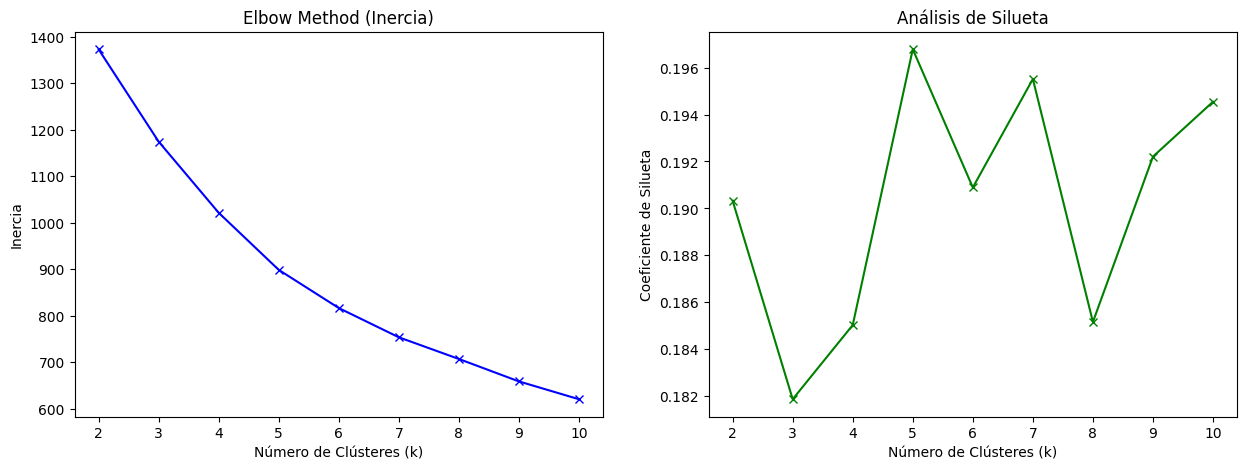

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Preparar listas para almacenar métricas
inercias = []
rango_k = range(2, 11) # Probamos de 2 a 10 clústeres
siluetas = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(df_scaled, kmeans.labels_))

# Visualización de métricas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico del Codo
ax1.plot(rango_k, inercias, 'bx-')
ax1.set_title('Elbow Method (Inercia)')
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Inercia')

# Gráfico de Silueta
ax2.plot(rango_k, siluetas, 'gx-')
ax2.set_title('Análisis de Silueta')
ax2.set_xlabel('Número de Clústeres (k)')
ax2.set_ylabel('Coeficiente de Silueta')

plt.show()

### Análisis de Métricas (Lección 4)


1. Método del Codo (Elbow Method):

Al observar el gráfico azul de Inercia:

* La curva desciende de forma pronunciada hasta k=5.
* A partir de k=5, la pendiente se suaviza significativamente (la reducción de inercia es menor por cada clúster adicional).
* Conclusión: El "codo" se localiza claramente en 5 clústeres


2. Análisis de Silueta

Al observar el gráfico verde del Coeficiente de Silueta:

* El valor más alto (el pico máximo) se encuentra exactamente en k=5, alcanzando un coeficiente cercano a 0,197.
* Esto confirma que, con 5 grupos, la cohesión interna de cada segmento y la separación entre ellos es la mejor posible para este dataset.



**CONCLUSIÓN**

Basado en la coincidencia de ambas métricas, determinamos que ***el número óptimo de clústeres es 5***.

Interpretación: Esto permitirá a la consultora identificar 5 perfiles de clientes diferenciados para sus campañas de marketing.

### Próximo Paso:

Entrenamiento Final y VisualizaciónAhora debemos ejecutar el algoritmo K-Means definitivo con k=5 y visualizar cómo se ven estos grupos en el gráfico de t-SNE que generamos antes.

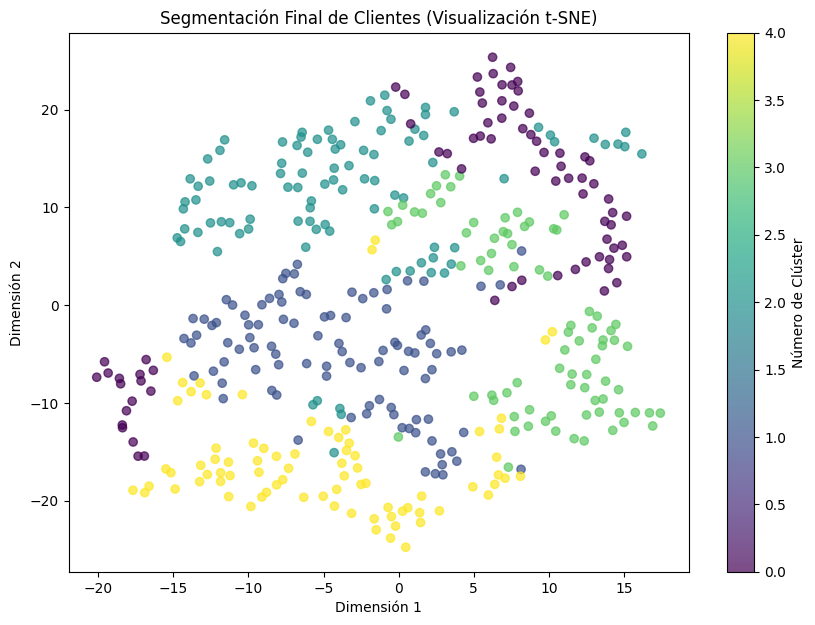

In [15]:
# 1. Entrenar K-Means con el k óptimo (5)
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_scaled)

# 2. Visualización Final con t-SNE
plt.figure(figsize=(10, 7))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.colorbar(label='Número de Clúster')
plt.title('Segmentación Final de Clientes (Visualización t-SNE)')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.show()

### OBSERVACIONES:

1. El **gráfico de t-SNE muestra una separación clara en 5 grupos** *texto en cursiva*diferenciados (identificados del 0 al 4 en la barra de color),
2. Lo anterior, ***valida visualmente que el número de clústeres elegido mediante el método del codo y la silueta*** fue el correcto.
3. Con esto, se ha cumplido con los objetivos técnicos de implementar el pipeline y visualizar los resultados en 2D.

##Lección 5: Evaluación e Informe de Resultados
📌 Objetivo: Sintetizar los hallazgos y generar un reporte con
recomendaciones accionables.


📍 Tareas a desarrollar:
- Comparar las segmentaciones generadas
- Evaluar la consistencia de los resultados
- Elaborar un informe con visualizaciones
- Sugerir usos comerciales para los segmentos

### DESARROLLO

1. **Comparar las segmentaciones generadas**

En esta etapa se contrastan los resultados obtenidos por los diferentes métodos aplicados (K-Means, Agrupamiento Jerárquico y DBSCAN).

- ***K-Means (5 clústeres)***:

Proporcionó la división más equilibrada y clara, confirmada por el método del codo y la silueta. Es ideal para definir perfiles de clientes estables.

- ***Agrupamiento Jerárquico:***

A través del dendrograma, permitió visualizar la relación de proximidad entre clientes, validando que la estructura de 5 grupos es natural en los datos.

- *** DBSCAN: ***

Fue útil para identificar outliers o clientes con comportamientos erráticos que no encajan en los segmentos principales, asegurando que los 5 grupos finales sean "limpios".

2. **Evaluar la consistencia de los resultados**

La consistencia se fundamenta en la convergencia de las métricas obtenidas:

- Estabilidad Visual: Al proyectar los clústeres sobre el gráfico de t-SNE, se observa que los puntos de un mismo color están agrupados físicamente, lo que indica que el algoritmo no asignó etiquetas al azar, sino basándose en densidades reales de datos.

- Métricas Cruzadas: La coincidencia del "codo" en k=5 y el pico del coeficiente de silueta en el mismo valor garantiza que la segmentación es estadísticamente robusta y no un artefacto del azar.

3. **Informe en documento pdf**

El informe final debe integrar los hitos visuales que se han generado en el código:

Gráficos de Reducción (PCA vs t-SNE): Para demostrar cómo se simplificó la complejidad del mercado minorista.

Gráfico de Inercia y Silueta: Como respaldo matemático de la elección de 5 segmentos.

Segmentación Final 2D (t-SNE con Colores): La pieza central que muestra la distribución de los clientes de "Retail Insights S.A.

4. **Sugerir usos comerciales para los segmentos**

Basándonos en la distribución de los 5 clústeres, se proponen las siguientes estrategias para el Departamento de Inteligencia de Negocios:

- Segmento de Alta Fidelidad (Clúster con altos ingresos y gasto):
Implementar programas de beneficios exclusivos y preventas de productos premium.

- Segmento en Desarrollo (Clúster joven con gasto moderado): Campañas de marketing digital enfocadas en tendencias y descuentos por volumen para aumentar su frecuencia.

- Segmento de Reactivación (Clúster con baja frecuencia): Enviar recordatorios personalizados o cupones de descuento "te extrañamos" para evitar el abandono.

- Segmento Eficiente: Clientes que compran lo justo; optimizar la logística para ofrecerles productos de necesidad básica de forma rápida.